# Publication-style SED figures (paper Fig. 4 & 5 style)

This notebook draws the hadronic and leptonic models as spectral energy
distributions in the style of Figs. 3-5 of Hnatyk et al. 2022, using the
**reusable functions in [`plotting.py`](../plotting.py)**.

The whole design is: each plotting function takes a **parameter vector** as its
first argument, so you simply pass in the best fit you want to display —

```python
plot_hadronic_sed(pars, data=..., hawc=...)   # pars = [log10 N0_p, G_p, log10(Ecut/TeV), Kep, n_H]
plot_leptonic_sed(pars, data=..., hawc=...)   # pars = [log10 N0_e, G_e, log10(Ecut/TeV)]
```

No MCMC runs here — you provide the parameters. Use the paper/module defaults
(`H.INITIAL`, `L.INITIAL`) to reproduce the published figures, **or paste the
posterior medians from a fit notebook to display your own fit** (see the next
cell). The same functions can be called directly at the end of a fitting
notebook to see your result immediately.

## Setup

In [1]:
import sys; from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline

from spectrum_tools import load_spectrum
from naima_models import hadronic as H, leptonic as L
from plotting import plot_hadronic_sed, plot_leptonic_sed, plot_comparison

# Data to overlay (real baseline + HAWC for comparison). Swap for the flat
# 0.2F set ('combined_fermi_hess.ecsv' + 'hawc_3hwc_j1907.ecsv') for the dense
# point look of the paper figures.
data = load_spectrum('../spectra/combined_real_baseline.ecsv')
hawc = load_spectrum('../spectra/hawc_3hwc_propagated.ecsv')

## Choose which parameters to plot

By default we use the **paper best fit** (`H.INITIAL` / `L.INITIAL`, referenced
to E0 = 1 TeV) — this reproduces the published figures and the published
W_p / W_e.

**To display your own fit instead**, run a fitting notebook, copy the median
vector printed in its Section 5, and paste it here. For example a leptonic fit
prints something you can transcribe as `np.array([35.54, 3.00, 2.97])`. The
legend's W_e then reflects *your* fit, which may differ from the paper (W_e is
sensitive to the electron index, normalisation and E_e,min — see the fit
notebook's conclusion).

In [2]:
# Paper best fit (default). Replace either line with your own fitted medians.
HAD_PARS = H.INITIAL.copy()    # [log10 N0_p, Gamma_p, log10(Ecut/TeV), Kep, n_H]
LEP_PARS = L.INITIAL.copy()    # [log10 N0_e, Gamma_e, log10(Ecut/TeV)]

# e.g. to show a leptonic fit you obtained:
# LEP_PARS = np.array([35.54, 3.00, 2.97])

print('hadronic pars:', np.round(HAD_PARS, 3))
print('leptonic pars:', np.round(LEP_PARS, 3))

hadronic pars: [3.689e+01 2.410e+00 2.268e+00 4.000e-03 9.810e+00]
leptonic pars: [35.62   3.08   2.628]


## Hadronic model (Fig. 4 style)
PionDecay (legend shows $W_p$) + the co-accelerated electrons' Inverse Compton
(CMB/IR/NIR) + Synchrotron at B = 1 and 5 µG.

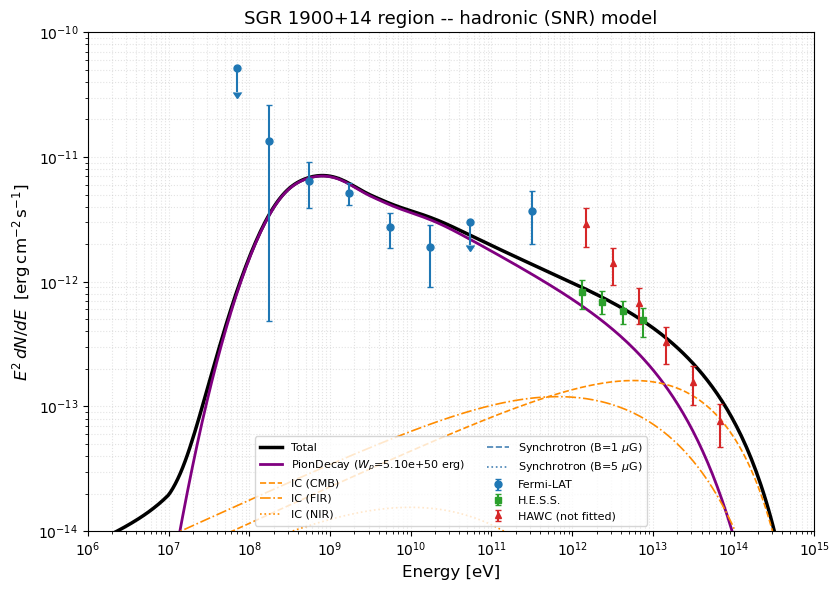

In [3]:
ax = plot_hadronic_sed(HAD_PARS, data=data, hawc=hawc)
plt.tight_layout(); plt.show()

## Leptonic model (Fig. 5 style)
Total Inverse Compton (legend shows $W_e$) split into the CMB/FIR/NIR seed
fields, plus Synchrotron at B = 1 and 5 µG.

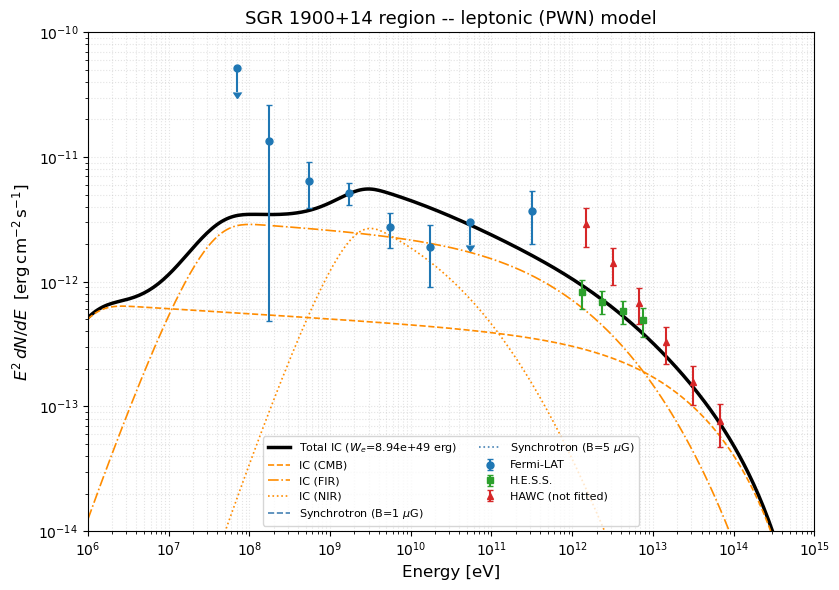

In [4]:
ax = plot_leptonic_sed(LEP_PARS, data=data, hawc=hawc)
plt.tight_layout(); plt.show()

## Side-by-side comparison
The two scenarios on the same data — the figure for judging which mechanism is
more plausible. (`components=True` would add all the sub-curves to each panel.)

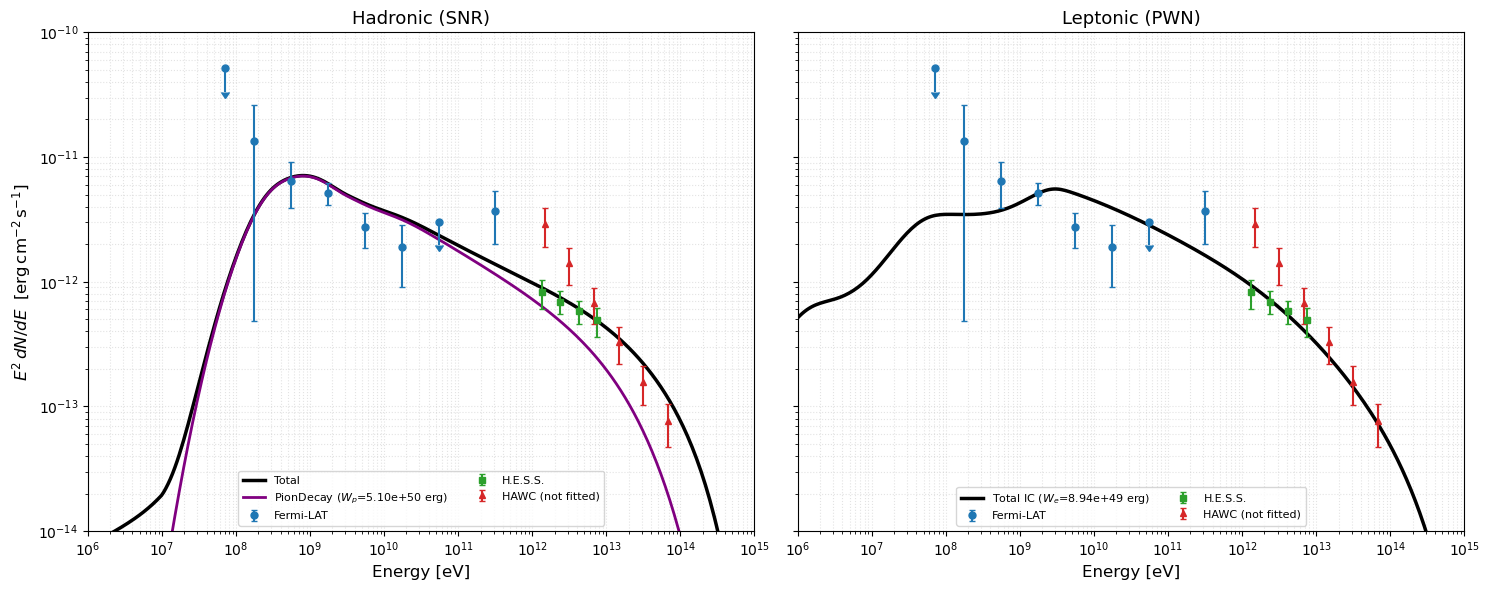

Saved sed_comparison.png


In [5]:
fig, axes = plot_comparison(HAD_PARS, LEP_PARS, data=data, hawc=hawc)
fig.savefig('sed_comparison.png', dpi=150)
plt.show()
print('Saved sed_comparison.png')

## Calling these from a fitting notebook
You don't need this notebook to see a fit — at the end of a fitting notebook,
once you have the posterior medians, just call the same function:

```python
from plotting import plot_leptonic_sed
q50 = np.percentile(sampler.get_chain(flat=True), 50, axis=0)
plot_leptonic_sed(q50, data=data, hawc=hawc)
```

### Customising
- Every function returns the matplotlib `Axes`, so you can keep tweaking
  (`ax.set_xlim(...)`, add a CTA sensitivity curve, etc.).
- `components=False` plots only the total (clean overlay).
- `sync_B=(1, 5)` sets which magnetic-field synchrotron curves to draw.
- Pass `egrid=...` to change the energy range/sampling of the model curves.